# Welcome to Colab!

## Google Colab is available in VS Code!
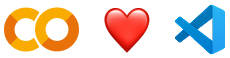

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


In [ ]:
import os
import random
import zipfile
from PIL import Image, ImageEnhance

# Paths configuration
ZIP_PATH = "/content/WasteDataset.zip"
EXTRACT_DIR = "/content/WasteDataset_extracted"
OUTPUT_DIR = "/content/resized_augmented_images"
TARGET_SIZE = (1600, 1600)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Unzip the archive
if os.path.exists(ZIP_PATH):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Unzip complete.")
else:
    raise FileNotFoundError(f"Could not find zip file at {ZIP_PATH}")

# 2. Augmentation Helper Function
def get_augmentations(img):
    """Generates 3 augmented variations of an image."""
    aug_images = []

    # Augmentation 1: Horizontal Flip
    h_flip = img.transpose(Image.FLIP_LEFT_RIGHT)
    aug_images.append(("_aug_hflip", h_flip))

    # Augmentation 2: Random Rotation (-15° or +15°)
    angle = random.choice([-15, 15])
    rotated = img.rotate(angle, resample=Image.Resampling.BILINEAR, expand=False)
    aug_images.append((f"_aug_rot{angle}", rotated))

    # Augmentation 3: Brightness Adjustment (80% or 120%)
    factor = random.choice([0.8, 1.2])
    bright = ImageEnhance.Brightness(img).enhance(factor)
    aug_images.append((f"_aug_bright{int(factor*100)}", bright))

    return aug_images

# 3. Process, Resize, and Augment
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
orig_count = 0
aug_count = 0

for root, _, filenames in os.walk(EXTRACT_DIR):
    for filename in filenames:
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(root, filename)
            base_name, _ = os.path.splitext(filename)

            try:
                with Image.open(img_path) as img:
                    if img.mode in ("RGBA", "P"):
                        img = img.convert("RGB")

                    # Resize original
                    img.thumbnail(TARGET_SIZE, Image.Resampling.LANCZOS)

                    # Save original resized image
                    orig_name = f"{base_name}_orig.jpg"
                    img.save(os.path.join(OUTPUT_DIR, orig_name), quality=90)
                    orig_count += 1

                    # Generate and save augmentations
                    for suffix, aug_img in get_augmentations(img):
                        aug_name = f"{base_name}{suffix}.jpg"
                        aug_img.save(os.path.join(OUTPUT_DIR, aug_name), quality=90)
                        aug_count += 1

            except Exception as e:
                print(f"Skipped {filename}: {e}")

print(f"Done! Saved {orig_count} original + {aug_count} augmented = {orig_count + aug_count} total images into '{OUTPUT_DIR}'.")

Unzipping dataset...
Unzip complete.
Done! Saved 40 original + 120 augmented = 160 total images into '/content/resized_augmented_images'.


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  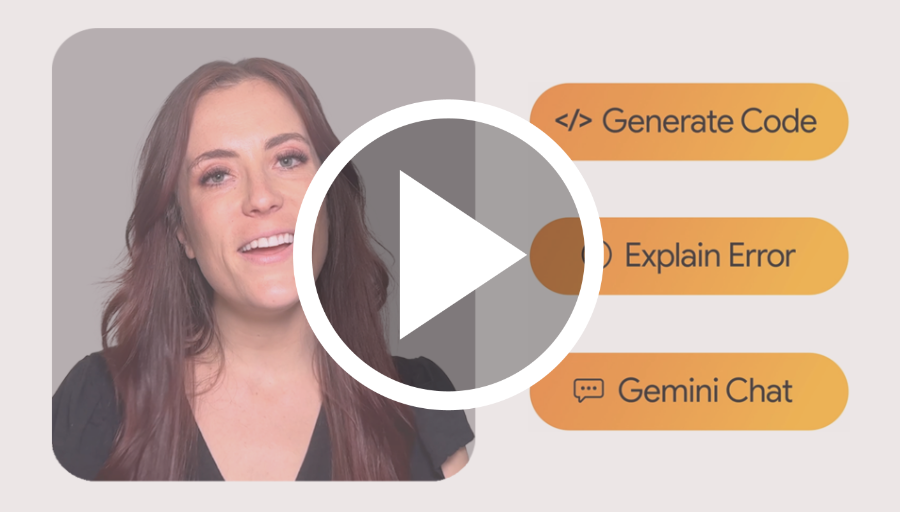
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

Unzipping dataset...
✅ Found 4 classes: ['Metal', 'Plastic', 'Organic', 'Paper']

Processing, augmenting, and splitting dataset...
Found 128 files belonging to 4 classes.
Found 16 files belonging to 4 classes.
Found 16 files belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training Transfer Learning Model...
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2578 - loss: 1.8166 - val_accuracy: 0.6875 - val_loss: 1.0681
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4844 - loss: 1.2572 - val_accuracy: 0.7500 - val_loss: 0.7657
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6953 - loss: 0.8601 - val_accuracy: 0.8125 - val_loss: 0.4989
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8281 - loss: 0.5906 - val_accuracy: 1.0000 - val_loss: 0.3742
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8594 - loss: 0.4016 - val_accuracy: 1.0000 - val_loss: 0.3186
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step 

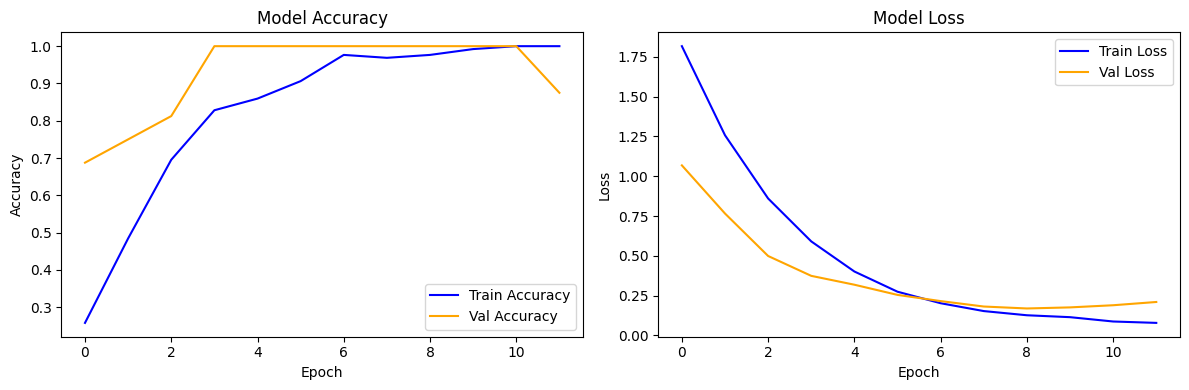

In [ ]:
import os
import random
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageEnhance

# -------------------------------------------------------------
# 1. Configuration & Paths
# -------------------------------------------------------------
ZIP_PATH = "/content/WasteDataset.zip"
EXTRACT_DIR = "/content/extracted"
SPLIT_DIR = "/content/dataset_split"

IMAGE_SIZE = (224, 224)  # Standard resolution for CNNs
BATCH_SIZE = 32
EPOCHS = 10

# Clean up any leftover folders from previous runs
for path in [EXTRACT_DIR, SPLIT_DIR]:
    if os.path.exists(path):
        shutil.rmtree(path)

# -------------------------------------------------------------
# 2. Unzip and Detect Class Folders Automatically
# -------------------------------------------------------------
if os.path.exists(ZIP_PATH):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
else:
    raise FileNotFoundError(f"Could not find zip file at {ZIP_PATH}")

valid_exts = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
class_folders = {}  # Maps class_name -> list of image file paths

for root, _, files in os.walk(EXTRACT_DIR):
    if "__MACOSX" in root:
        continue
    img_files = [os.path.join(root, f) for f in files if f.lower().endswith(valid_exts)]
    if img_files:
        class_name = os.path.basename(root)
        if class_name in class_folders:
            class_folders[class_name].extend(img_files)
        else:
            class_folders[class_name] = img_files

print(f"✅ Found {len(class_folders)} classes: {list(class_folders.keys())}")

if not class_folders:
    raise ValueError("No valid images were found inside the zip file.")

# -------------------------------------------------------------
# 3. Resize, Augment, and Split into Train/Val/Test
# -------------------------------------------------------------
def process_and_save(src_path, dest_prefix):
    """Resizes and generates 3 augmented versions directly into target split."""
    try:
        with Image.open(src_path) as img:
            img = img.convert("RGB").resize(IMAGE_SIZE)

            # Original
            img.save(f"{dest_prefix}_orig.jpg")
            # Horizontal Flip
            img.transpose(Image.FLIP_LEFT_RIGHT).save(f"{dest_prefix}_flip.jpg")
            # Rotation
            img.rotate(random.choice([-15, 15])).save(f"{dest_prefix}_rot.jpg")
            # Brightness
            ImageEnhance.Brightness(img).enhance(1.2).save(f"{dest_prefix}_bright.jpg")
    except Exception:
        pass

print("\nProcessing, augmenting, and splitting dataset...")
for class_name, paths in class_folders.items():
    random.shuffle(paths)
    n_total = len(paths)
    n_train = int(n_total * 0.8)
    n_val = int(n_total * 0.1)

    splits = {
        'train': paths[:n_train],
        'val': paths[n_train:n_train + n_val],
        'test': paths[n_train + n_val:]
    }

    for split_name, split_paths in splits.items():
        split_class_dir = os.path.join(SPLIT_DIR, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for idx, p in enumerate(split_paths):
            dest_prefix = os.path.join(split_class_dir, f"img_{idx}")
            process_and_save(p, dest_prefix)

# -------------------------------------------------------------
# 4. Load Keras Datasets
# -------------------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/train", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/val", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/test", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)

num_classes = len(train_ds.class_names)

# -------------------------------------------------------------
# 5. Build Model using Transfer Learning (MobileNetV2)
# -------------------------------------------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

model = tf.keras.Sequential([
    # MobileNetV2 expects pixel values scaled to [-1, 1]
    tf.keras.layers.Rescaling(1./127.5, offset=-1, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),  # Prevents overfitting
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------------------------------------
# 6. Train Model with Early Stopping
# -------------------------------------------------------------
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print("\nTraining Transfer Learning Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

# -------------------------------------------------------------
# 7. Evaluate on Test Data
# -------------------------------------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n🎯 Final Test Accuracy: {test_acc * 100:.2f}%")

# -------------------------------------------------------------
# 8. Plot Accuracy and Loss Graphs
# -------------------------------------------------------------
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

Unzipping dataset...
✅ Found 4 classes: ['Metal', 'Plastic', 'Organic', 'Paper']

Processing, augmenting, and splitting dataset...
Found 128 files belonging to 4 classes.
Found 16 files belonging to 4 classes.
Found 16 files belonging to 4 classes.

Training Transfer Learning Model...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1797 - loss: 2.0050 - val_accuracy: 0.1250 - val_loss: 2.1040
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4141 - loss: 1.3200 - val_accuracy: 0.2500 - val_loss: 1.6866
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6094 - loss: 0.9435 - val_accuracy: 0.6875 - val_loss: 1.4603
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8203 - loss: 0.5974 - val_accuracy: 0.6875 - val_loss: 1.2780
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8906 - loss: 0.3784 - val_accuracy: 0.6875 - val_loss: 1.0799
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9453 - loss: 0.3109 - val_accuracy:

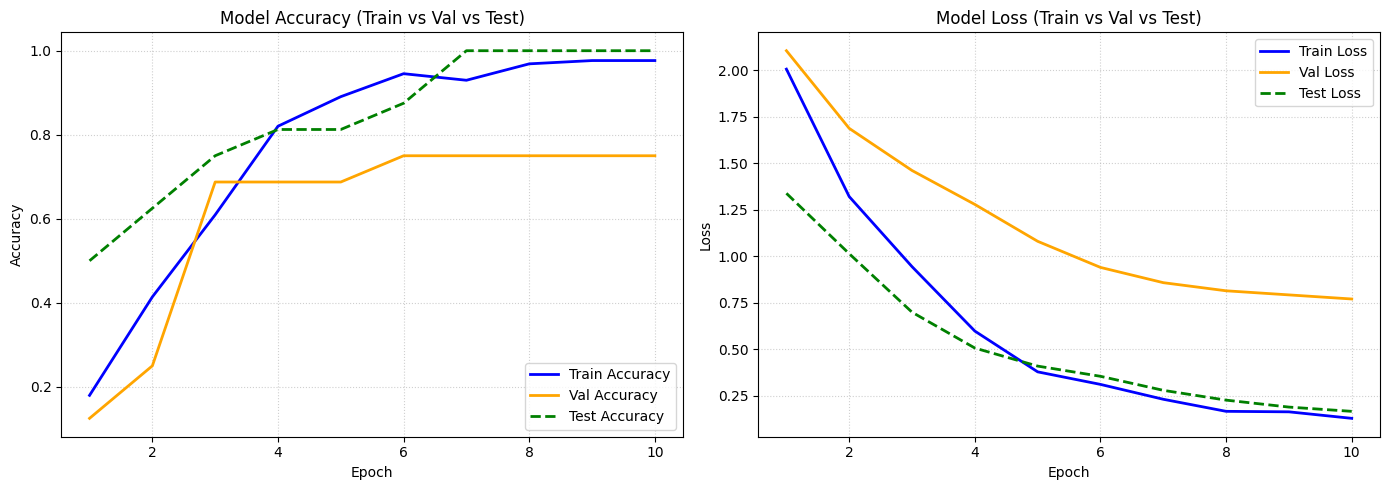

In [ ]:
import os
import random
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageEnhance

# -------------------------------------------------------------
# 1. Configuration & Paths
# -------------------------------------------------------------
ZIP_PATH = "/content/WasteDataset.zip"
EXTRACT_DIR = "/content/extracted"
SPLIT_DIR = "/content/dataset_split"

IMAGE_SIZE = (224, 224)  # Standard resolution for MobileNetV2
BATCH_SIZE = 32
EPOCHS = 10

# Clean up leftover folders from previous runs
for path in [EXTRACT_DIR, SPLIT_DIR]:
    if os.path.exists(path):
        shutil.rmtree(path)

# -------------------------------------------------------------
# 2. Unzip and Detect Class Folders Automatically
# -------------------------------------------------------------
if os.path.exists(ZIP_PATH):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
else:
    raise FileNotFoundError(f"Could not find zip file at {ZIP_PATH}")

valid_exts = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
class_folders = {}

for root, _, files in os.walk(EXTRACT_DIR):
    if "__MACOSX" in root:
        continue
    img_files = [os.path.join(root, f) for f in files if f.lower().endswith(valid_exts)]
    if img_files:
        class_name = os.path.basename(root)
        if class_name in class_folders:
            class_folders[class_name].extend(img_files)
        else:
            class_folders[class_name] = img_files

print(f"✅ Found {len(class_folders)} classes: {list(class_folders.keys())}")

# -------------------------------------------------------------
# 3. Resize, Augment, and Split into Train/Val/Test
# -------------------------------------------------------------
def process_and_save(src_path, dest_prefix):
    """Resizes and generates 3 augmented versions directly into target split."""
    try:
        with Image.open(src_path) as img:
            img = img.convert("RGB").resize(IMAGE_SIZE)

            # Original
            img.save(f"{dest_prefix}_orig.jpg")
            # Horizontal Flip
            img.transpose(Image.FLIP_LEFT_RIGHT).save(f"{dest_prefix}_flip.jpg")
            # Rotation
            img.rotate(random.choice([-15, 15])).save(f"{dest_prefix}_rot.jpg")
            # Brightness
            ImageEnhance.Brightness(img).enhance(1.2).save(f"{dest_prefix}_bright.jpg")
    except Exception:
        pass

print("\nProcessing, augmenting, and splitting dataset...")
for class_name, paths in class_folders.items():
    random.shuffle(paths)
    n_total = len(paths)
    n_train = int(n_total * 0.8)
    n_val = int(n_total * 0.1)

    splits = {
        'train': paths[:n_train],
        'val': paths[n_train:n_train + n_val],
        'test': paths[n_train + n_val:]
    }

    for split_name, split_paths in splits.items():
        split_class_dir = os.path.join(SPLIT_DIR, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for idx, p in enumerate(split_paths):
            dest_prefix = os.path.join(split_class_dir, f"img_{idx}")
            process_and_save(p, dest_prefix)

# -------------------------------------------------------------
# 4. Load Keras Datasets
# -------------------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/train", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/val", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_DIR}/test", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)

num_classes = len(train_ds.class_names)

# -------------------------------------------------------------
# 5. Build Model using Transfer Learning (MobileNetV2)
# -------------------------------------------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./127.5, offset=-1, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------------------------------------
# 6. Custom Callback to Track Test Set Per Epoch
# -------------------------------------------------------------
class TestEvaluationCallback(tf.keras.callbacks.Callback):
    def __init__(self, test_dataset):
        super().__init__()
        self.test_dataset = test_dataset
        self.test_loss = []
        self.test_acc = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.test_dataset, verbose=0)
        self.test_loss.append(loss)
        self.test_acc.append(acc)

test_callback = TestEvaluationCallback(test_ds)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# -------------------------------------------------------------
# 7. Train Model
# -------------------------------------------------------------
print("\nTraining Transfer Learning Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, test_callback]
)

# -------------------------------------------------------------
# 8. Evaluate & Print Final Results
# -------------------------------------------------------------
final_test_loss, final_test_acc = model.evaluate(test_ds)
print(f"\n🎯 Final Test Accuracy: {final_test_acc * 100:.2f}%")

# -------------------------------------------------------------
# 9. Plot Accuracy and Loss Graphs (Train vs Val vs Test)
# -------------------------------------------------------------
epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.plot(epochs_range, test_callback.test_acc, label='Test Accuracy', color='green', linestyle='--', linewidth=2)
plt.title('Model Accuracy (Train vs Val vs Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs_range, history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.plot(epochs_range, test_callback.test_loss, label='Test Loss', color='green', linestyle='--', linewidth=2)
plt.title('Model Loss (Train vs Val vs Test)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
